# Seminar 12

# ADMM

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib
import cvxpy as cvx

In [2]:
%matplotlib inline

matplotlib.use('Agg')
params = {'legend.fontsize': 20,
          'legend.handlelength': 4,
          "axes.labelsize": 45,
          "xtick.labelsize": 25,
          "ytick.labelsize": 25,
          "lines.linewidth": 4,
           "axes.titlesize":30}
matplotlib.rcParams.update(params)

In [3]:
class ADMM:
    def __init__(self, rho=1, max_iters=1000, mu=10, tau_incr=2, tau_decr=2, 
                 adaptive=False, return_history=False):
        self.rho = rho
        self.max_iters = max_iters
        self.return_history = return_history
        self.history = []
        self.mu = mu
        self.tau_incr = tau_incr
        self.tau_decr = tau_decr
        self.adaptive = adaptive
        
    def solve(self, x0, z0, y0, solve_first_term, solve_second_term, 
              calculate_equation, obj_function=None, print_iter=None):
        x = x0.copy()
        z = z0.copy()
        y = y0.copy()
        self.history = [((x, z, y), time.time())]
        rho = self.rho
        r = None,
        for i in range(self.max_iters):
            x = solve_first_term(x, z, y, self.rho)
            z_prev, z = z, solve_second_term(x, z, y, self.rho)
            r = calculate_equation(x, z)
            y += r
            
            norm_r = np.linalg.norm(r)
            norm_dual_resid = self.rho * np.linalg.norm(z_prev-z)
            if self.adaptive:
                if norm_r >= self.mu * norm_dual_resid:
                    self.rho *= self.tau_incr
                    y /= self.tau_incr
                if norm_dual_resid >= self.mu * norm_r:
                    self.rho /= self.tau_decr
                    y *= self.tau_incr
                    
            if print_iter is not None and i % print_iter == 0:
                print("iteration:\t", i)
                print("rho_val:\t", self.rho)
                print("prime_res:\t", norm_r)
                if obj_function is not None:
                    print("obj_val:\t", obj_function(x, z))
                print()
            if self.return_history:
                self.history.append(((x, z, y), time.time()))
        return x, z, y

## 1. Robust PCA: Proximal methods vs ADMM

$$\min_{X_1, X_2, X_3} \frac{1}{2}\|X_1\|_F^2 + \lambda_1 \|X_2\|_{\ell_1} + \lambda_2 \|X_3\|_*,$$
$$\text{s.t. } A = X_1 + X_2 + X_3.$$

$$L_{rho}(X_1, X_2, X_3, Y) = \frac{1}{2}\|X_1\|_F^2 + \lambda_1 \|X_2\|_{\ell_1} + \lambda_2 \|X_3\|_* + \frac{\rho}{2} \|A - (X_1 + X_2 + X_3) + Y\|_F^2$$

$$X=[X_1, X_2], Z=[X_3]$$

$$X_2^{k+1} = prox_{\frac{\lambda_1(1+\rho) \|\cdot\|}{\rho}}\left(A - X_3^k + Y^k\right);X_1^{k+1}=\frac{\rho}{1+\rho}\left(A - (X_2^{k+1} + X_3^k) + Y^k\right)$$

$$X_3^{k+1} = \text{prox}_{\frac{\lambda_2}{\rho}\|\cdot\|_*}\left(A - X_1^{k+1} - X_2^{k+1}+Y\right)$$

In [4]:
class ProxGM:
    def __init__(self, fix_lam=None, lam0=1, beta=0.5, return_history=True, name=None):
        self.name = name
        self.return_history = return_history
        self.history = []
        self.lam0 = lam0
        self.fix_lam = fix_lam
        self.beta = beta
    
    def backtracking(self, x, f, gradf, g_prox):
        lam = self.lam0
        f_x = f(x)
        f_grad_x = gradf(x)
        z = g_prox(x - lam * f_grad_x, lam)
        while f(z) > f_x + np.sum(f_grad_x*(z - x)) + np.linalg.norm(z - x)**2 / (2 * lam):
            lam = lam * self.beta
            z = g_prox(x - lam * gradf(x), lam)
            self.lam0 = lam
            if lam <= 1e-9:
                break
        return z
    
    def solve(self, x0, f, gradf, g_prox, tol=1e-3, max_iter=10000):
        x = x0.copy()
        self.history = [(x, time.time())]
        for i in range(max_iter):
            if self.fix_lam is None:
                x = self.backtracking(x, f, gradf, g_prox)
            else:
                x_ = x - self.fix_lam * gradf(x)
                x = g_prox(x_, self.fix_lam)
            self.history.append((x, time.time()))
        return x

In [6]:
class AccProxGM(ProxGM):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
    
    def solve(self, x0, f, gradf, g_prox, tol=1e-3, max_iter=10000):
        x = x0.copy()
        x_prev = x.copy()
        self.history = [(x, time.time())]
        t_prev = 1
        t_next = (1 + np.sqrt(1 + 4 * t_prev**2)) / 2.
        for i in range(max_iter):
            w = (t_prev - 1) / t_next
            x, x_prev = x + w * (x - x_prev), x
            t_prev = t_next
            t_next = (1 + np.sqrt(1 + 4 * t_prev**2)) / 2.
            if self.fix_lam is None:
                x = self.backtracking(x, f, gradf, g_prox)
            else:
                x_ = x - self.fix_lam * gradf(x)
                x = g_prox(x_, self.fix_lam)
            self.history.append((x, time.time()))
        return x

In [7]:
class MatrixDecompose:
    def __init__(self, A, gamma2, gamma3):
        self.A = A
        self.gamma2 = gamma2
        self.gamma3 = gamma3
    
    def F(self, X):
        X0, X1 = X
        gamma2, gamma3 = self.gamma2, self.gamma3
        return self.f(X) + gamma2 * np.sum(np.abs(X0)) + gamma3 * np.linalg.norm(X[1], "nuc")

    def f(self, X):
        return 1/2 * np.linalg.norm(self.A - X.sum(0), ord="fro")**2

    def gradf(self, X):
        B = X.sum(0) - self.A
        G = np.array([B for _ in X])
        return G

    @staticmethod
    def entry_l1_prox(X, lam):
        return np.sign(X) * np.maximum(np.abs(X) - lam, 0) 

    @staticmethod
    def nuclear_norm_prox(X, lam):
        U, sigma, V = np.linalg.svd(X, full_matrices=False)
        return U.dot(np.diag(np.maximum(sigma - lam, 0))).dot(V)

    def g_prox(self, X, lam):
        X0 = self.entry_l1_prox(X[0], lam*self.gamma2)
        X1 = self.nuclear_norm_prox(X[1], lam*self.gamma3)
        return np.array([X0, X1])

In [8]:
def get_params_robust_PCA(problem, roundz=False):
    A = problem.A
    def solve_first_term(x, z, y, rho):
        x1, x2 = x
        tmp = problem.A - z + y
        x2 = MatrixDecompose.entry_l1_prox(tmp, problem.gamma2 * (1+rho) / (rho))
        x1 = rho / (1 + rho) * (A - x2 - z + y)
        return np.array([x1, x2])
    solve_second_term = lambda x, z, y, rho: MatrixDecompose.nuclear_norm_prox(A - x.sum(0) + y, problem.gamma3 / rho)
    calculate_equation = lambda x, z: A - x.sum(0) - z    
    def obj_function(x, z):
        return problem.F(np.array([x[-1], z]))
    return solve_first_term, solve_second_term, calculate_equation, obj_function

In [9]:
m = 1000
n = 200

np.random.seed(1)
a = np.random.rand(n)
m = len(a)
A = np.outer(a, np.ones(n))
np.random.seed(1)
S = 20 * np.random.rand(m * n) - 10
S[np.random.rand(m*n) < 0.7] = 0
S = S.reshape(m, n)
V = 0.05 * np.random.randn(m, n)

A = A + S + V
A = np.clip(A, 0, 1)

max_gamma_3 = np.linalg.norm(A, ord="nuc")
gamma_3 = 0.007 * max_gamma_3
max_gamma_2 = np.max(np.abs(A))
gamma_2 = 0.05 * max_gamma_2

problem = MatrixDecompose(A, gamma_2, gamma_3)

In [10]:
num_iter = 200
prox_method = AccProxGM(fix_lam=None, name="AccProxGM", return_history=True)
X_apm = prox_method.solve(np.zeros((2, n, m)), problem.f, problem.gradf, problem.g_prox, max_iter=num_iter)

In [17]:
x0 = np.zeros((2, n, m))
z0 = np.zeros((n, m))
y0 = np.zeros((n, m))
admm_method = ADMM(rho=0.5, max_iters=num_iter, return_history=True)
x, z, y = admm_method.solve(x0, z0, y0, *get_params_robust_PCA(problem), print_iter=None)

In [12]:
X2 = cvx.Variable((n, m))
X3 = cvx.Variable((n, m))
obj = (1/2 * cvx.norm(A - X2 - X3, p="fro")**2 + 
       gamma_2 * cvx.sum(cvx.abs(X2)) + 
       gamma_3 * cvx.norm(X3, p="nuc"))
min_val = cvx.Problem(cvx.Minimize(obj)).solve(solver="SCS", eps=1e-9, max_iters=300, verbose=False)

In [13]:
((x1, x2), x3, _), _ = admm_method.history[-1]
problem.F(np.array([x2, x3]))

900.4005637645264

In [14]:
problem.F(prox_method.history[-1][0])

900.400581246535

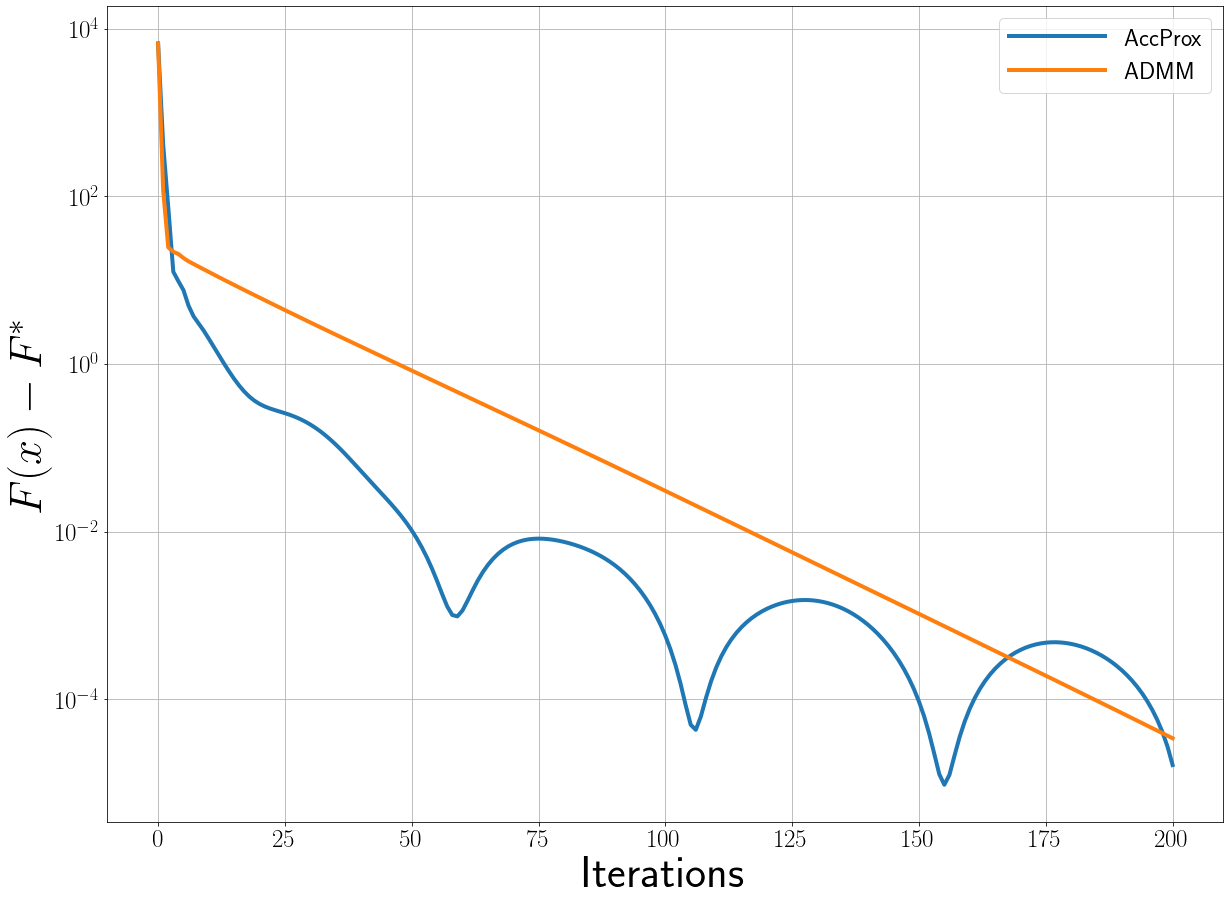

In [18]:
%matplotlib inline
plt.rc("text", usetex=True)
plt.figure(figsize=(20, 15))

hist = [problem.F(x) - min_val for x, _ in prox_method.history]
plt.semilogy(hist, label="AccProx")

hist = [problem.F(np.array([x2, x3])) - min_val for ((x1, x2), x3, _), _ in admm_method.history]
plt.semilogy(hist, label="ADMM")

plt.grid()
plt.xlabel("Iterations")
plt.ylabel(r"$F(x)-F^*$")
plt.legend(loc="best", fontsize=24)

## 2. General Lasso

$$\min_x \frac{1}{2}\|x-y\|^2 + \lambda\|Dx\|_1$$

Form for ADMM:

$$\min_x \frac{1}{2}\|x-y\|^2 + \lambda\|z\|_1$$
$$\text{s.t. } Dx = z$$

$$\frac{1}{2}\|x-y\|^2 + \lambda \sum\limits_{i=3}^n |x_i - 2x_{i-1}+x_{i-2}|$$

In [15]:
from scipy import sparse

def get_D(T):
    diags = [np.ones(T-2), -2 * np.ones(T-2), np.ones(T-2)]
    D = sparse.diags(diags, [0, 1, 2], shape=(T-2,T))
    return D

In [16]:
def get_params_general_lasso(init_data, lam=1, rho=1, roundz=False):
    n = len(init_data)
    D = get_D(n)
    inv_matrix = np.array(np.linalg.inv(np.eye(n) + rho * D.T @ D))
    solve_first_term = lambda x, z, y, rho: inv_matrix @ (init_data + rho * D.T @ (z - y))
    def solve_second_term(x, z, y, rho):
        tmp = D @ x + y
        return np.sign(tmp) * np.maximum(np.abs(tmp) - lam / rho, 0)
    calculate_equation = lambda x, z: D @ x - z
    obj_function = lambda x, z: 1/2 * np.linalg.norm(x - init_data)**2 + lam * np.linalg.norm(D @ x, ord=1)
    return solve_first_term, solve_second_term, calculate_equation, obj_function

In [17]:
np.random.seed(1)
n = 1000
m = 200

orig_data = np.tile(np.abs(np.arange(m) - m//2), n//m) * np.repeat(np.random.randn(n//m), m)
orig_data = orig_data / np.abs(orig_data).max()

noise_data = orig_data + np.random.randn(n)*1e-1

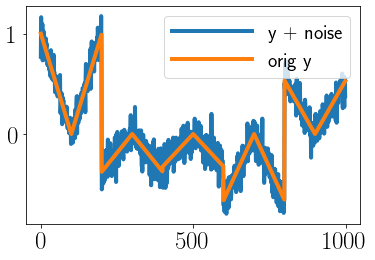

In [18]:
%matplotlib inline
plt.plot(noise_data, label="y + noise")
plt.plot(orig_data, label="orig y")
plt.legend()

In [19]:
lam = 4

In [20]:
D = get_D(n)
x = cvx.Variable(n)
obj = cvx.Minimize(1/2 * cvx.norm(x-noise_data)**2 + lam * cvx.sum(cvx.abs((D).toarray() @ x)))
min_val = cvx.Problem(obj).solve()

In [21]:
min_val

8.844187233577898

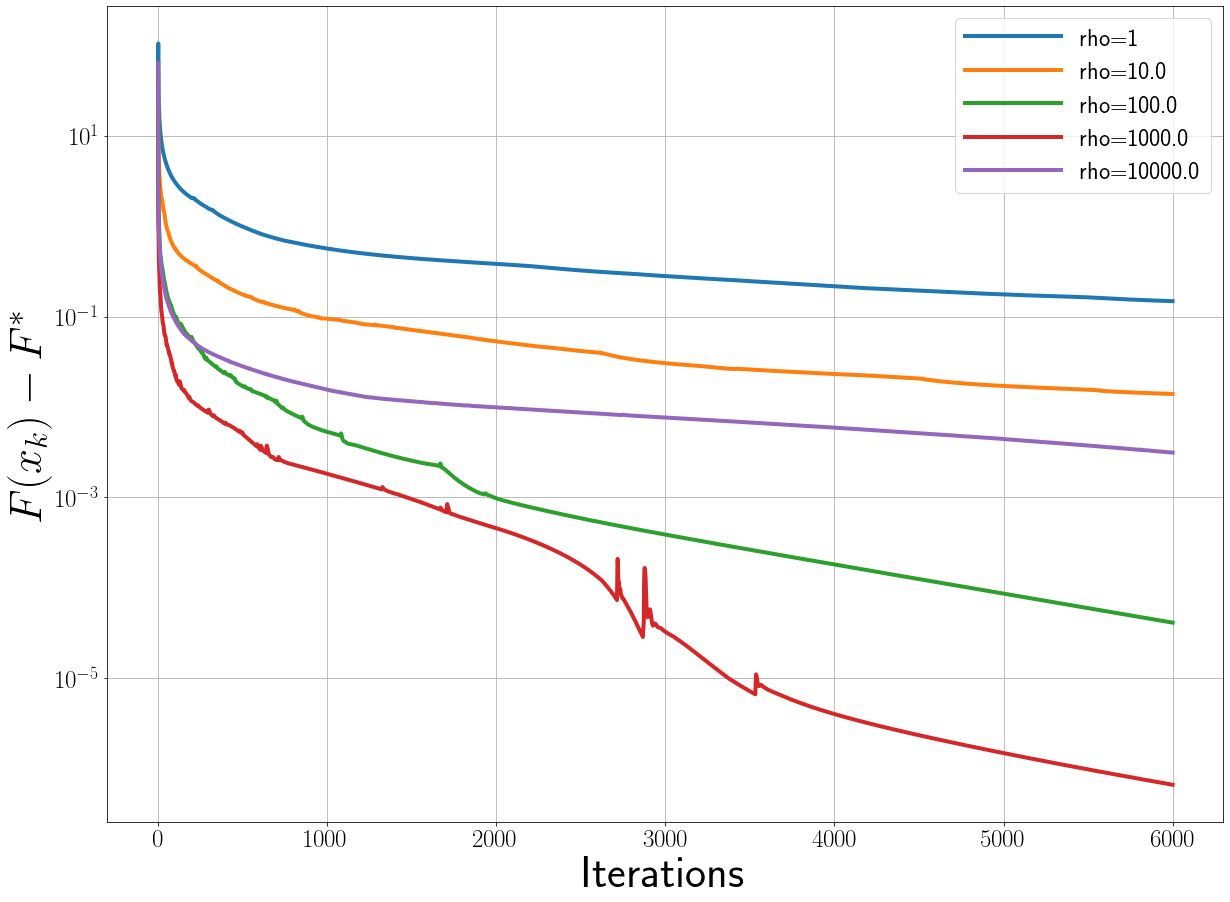

In [22]:
%matplotlib inline
plt.rc("text", usetex=True)
plt.figure(figsize=(20, 15))

F = lambda x: 1/2 * np.linalg.norm(x - noise_data)**2 + lam * np.linalg.norm(D @ x, ord=1)

for rho in [1, 1e1, 1e2, 1e3, 1e4]:
    x0 = np.zeros(n)
    z0 = np.zeros(n-2)
    y0 = np.zeros(n-2)

    method = ADMM(rho=rho, max_iters=6000, return_history=True)
    x, z, _ = method.solve(x0, z0, y0, *get_params_general_lasso(noise_data, lam=lam, rho=rho), print_iter=None)

    plt.semilogy([F(x)-min_val for (x, _, _), _ in method.history], label="rho={}".format(rho))


plt.grid()
plt.xlabel("Iterations")
plt.ylabel("$F(x_k)-F^*$")
plt.legend(loc="best", fontsize=24)

In [23]:
rho = 1e3
x0 = np.zeros(n)
z0 = np.zeros(n-2)
y0 = np.zeros(n-2)

method = ADMM(rho=rho, max_iters=6000, return_history=True)
x, z, _ = method.solve(x0, z0, y0, *get_params_general_lasso(noise_data, lam=lam, rho=rho), print_iter=1000)

iteration:	 0
rho_val:	 1000.0
prime_res:	 0.03424994052330548
obj_val:	 10.096133881695264

iteration:	 1000
rho_val:	 1000.0
prime_res:	 2.024062346761641e-06
obj_val:	 8.846009415955379

iteration:	 2000
rho_val:	 1000.0
prime_res:	 6.283880611714026e-07
obj_val:	 8.844643848604617

iteration:	 3000
rho_val:	 1000.0
prime_res:	 4.12477369715755e-07
obj_val:	 8.844219927524929

iteration:	 4000
rho_val:	 1000.0
prime_res:	 2.496516323253876e-08
obj_val:	 8.844191253195069

iteration:	 5000
rho_val:	 1000.0
prime_res:	 1.0104595629492397e-08
obj_val:	 8.844188722417684



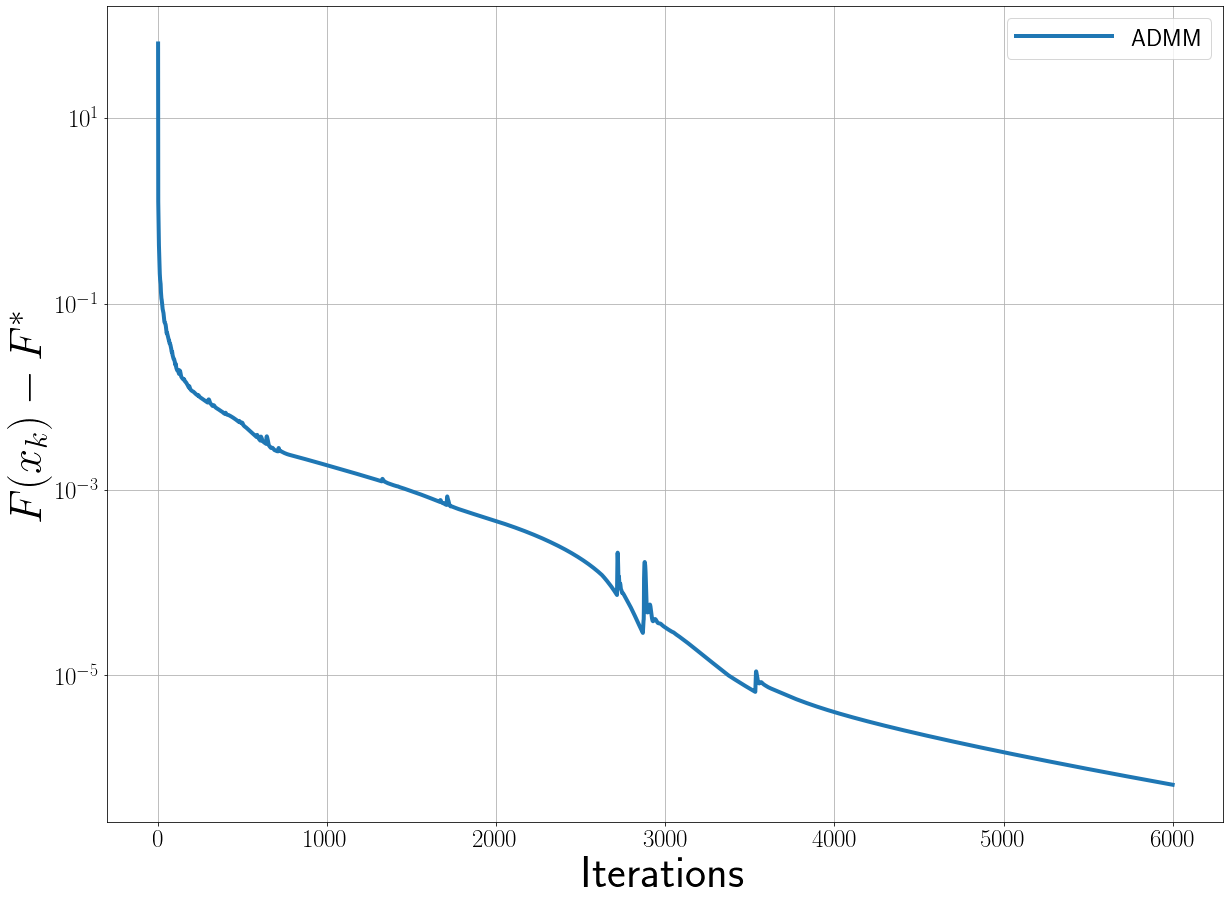

In [24]:
%matplotlib inline
plt.rc("text", usetex=True)
plt.figure(figsize=(20, 15))

F = lambda x: 1/2 * np.linalg.norm(x - noise_data)**2 + lam * np.linalg.norm(D @ x, ord=1)

plt.semilogy([F(x)-min_val for (x, _, _), _ in method.history], label="ADMM")


plt.grid()
plt.xlabel("Iterations")
plt.ylabel("$F(x_k)-F^*$")
plt.legend(loc="best", fontsize=24)

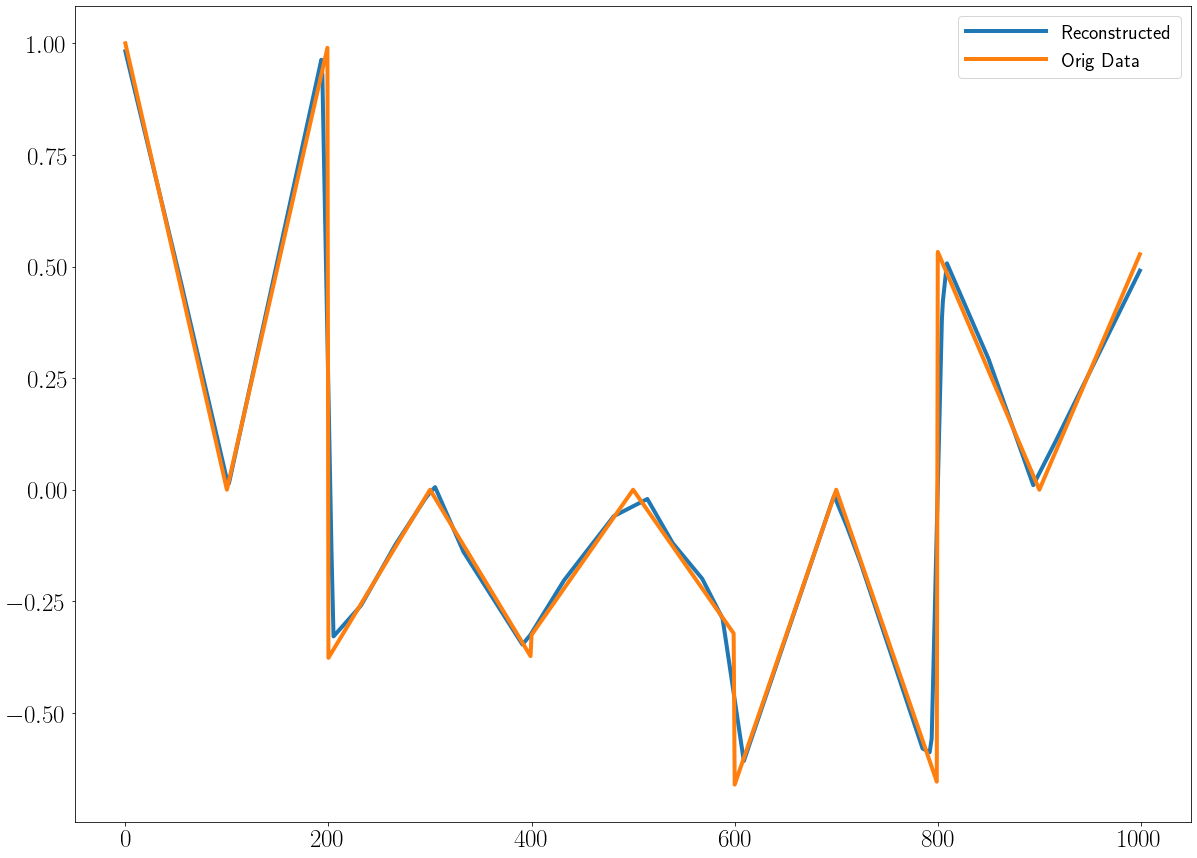

In [25]:
%matplotlib inline
plt.rc("text", usetex=True)
plt.figure(figsize=(20, 15))
plt.plot(x, label="Reconstructed")

plt.plot(orig_data, label="Orig Data")
plt.legend()

## 3. Linear Programming

$$\min c^\top x$$
$$Ax=b$$
$$x \in [0, 1]$$

The form for ADMM:


$$\min c^\top x$$
$$x - z = 0$$
$$Ax=b$$
$$z\in [0, 1]$$

$$L_{rho}(x, z, y) = c^\top x + I_{z\in [0,1]} (z) + \frac{\rho}{2}\left\|\begin{pmatrix}I \\ A\end{pmatrix} x + \begin{pmatrix}-I \\ 0\end{pmatrix} z - \begin{pmatrix}0 \\ b\end{pmatrix}+ y\right\|^2$$

Solve with respect to $x$:

$$x_{k+1} = -(I+A^\top A)^{-1}\left(-z_k - A^\top b + \begin{pmatrix}I & A^\top \end{pmatrix} y_k+\frac{1}{\rho} c\right)$$

Solve $z$:

$$z_{k+1} = \arg\min_{z\in [0,1]} \|x_{k+1}-z+ \begin{pmatrix}I_n & 0_{n\times m}\end{pmatrix} y_{k+1}\|^2$$

In [26]:
def get_params_LP(A, b, c, roundz=False):
    m, n = A.shape
    inv_matrix = np.linalg.inv(A @ A.T + np.eye(m))
    ATb = A.T @ b
    def solve_first_term(x, z, y, rho):
        q = -1/rho* c + z + ATb - y[:n] - A.T @ y[-m:]
        return q - A.T @ (inv_matrix @ (A @ q))
    solve_second_term = lambda x, z, y, rho: (np.clip(x + y[:n], 0, 1))
    calculate_equation = lambda x, z: np.hstack([x - z, A @ x - b])
    obj_function = lambda x, z: c.T @ x 
    return solve_first_term, solve_second_term, calculate_equation, obj_function

In [27]:
np.random.seed(1)
n, m = 1000, 100
A = np.random.randn(m, n)
c = np.random.rand(n)
b = A @ np.round(np.random.rand(n))
x0 = np.zeros(n)
z0 = np.zeros(n)
y0 = np.zeros(n + m)
rho = 100
method= ADMM(rho=rho, max_iters=20000, return_history=True)
x, z, y = method.solve(x0, z0, y0, *get_params_LP(A, b, c, rho), print_iter=None)

In [28]:
x = cvx.Variable(n)
min_val = cvx.Problem(cvx.Minimize(c.T @ x), [x>=0, x<=1, A@x == b]).solve()

(1000,) (1000,)


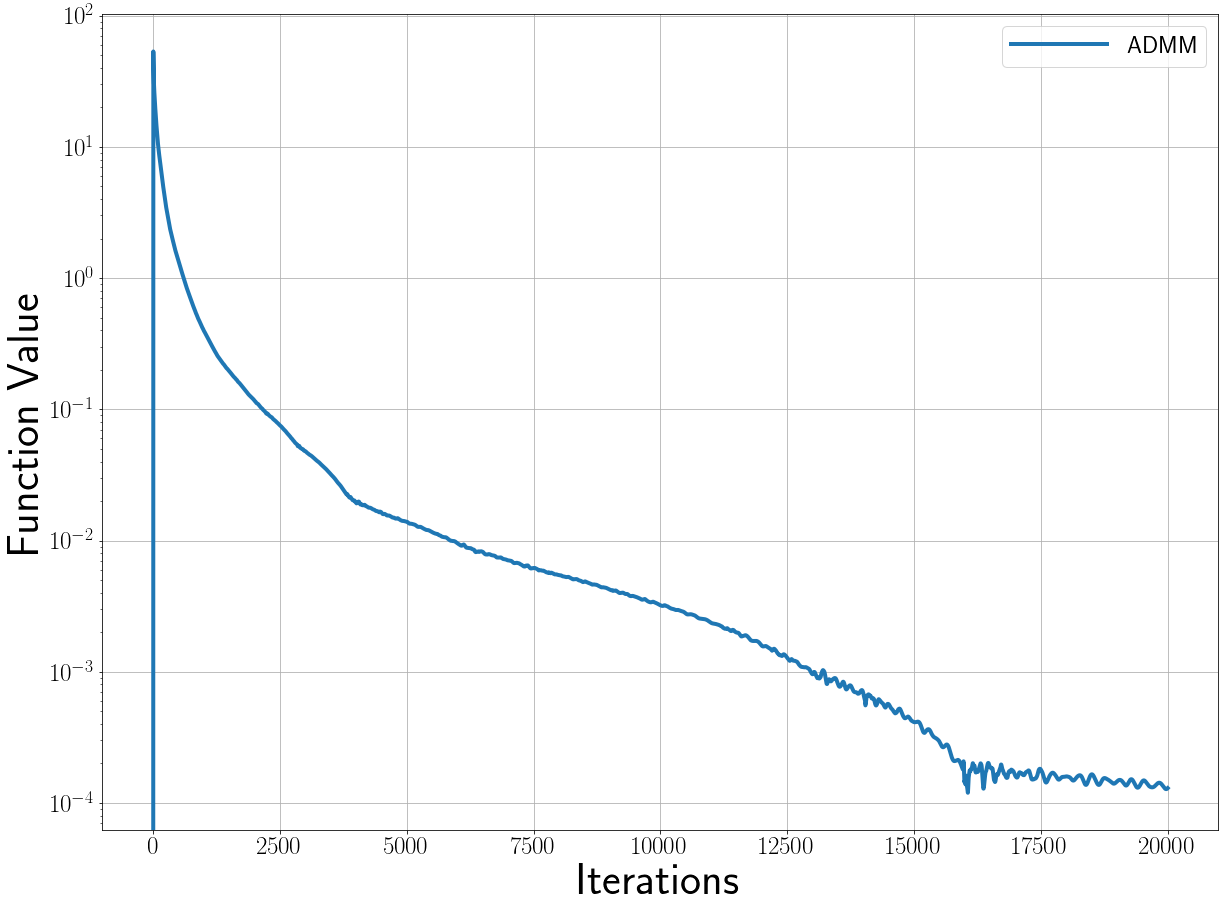

In [29]:
%matplotlib inline
plt.rc("text", usetex=True)
plt.figure(figsize=(20, 15))

print(c.shape, x.shape)


hist = [c.T @ z - min_val for (x, z, _), _ in method.history]
plt.semilogy(hist, label="ADMM")

plt.grid()
plt.xlabel("Iterations")
plt.ylabel("Function Value")
plt.legend(loc="best", fontsize=24)

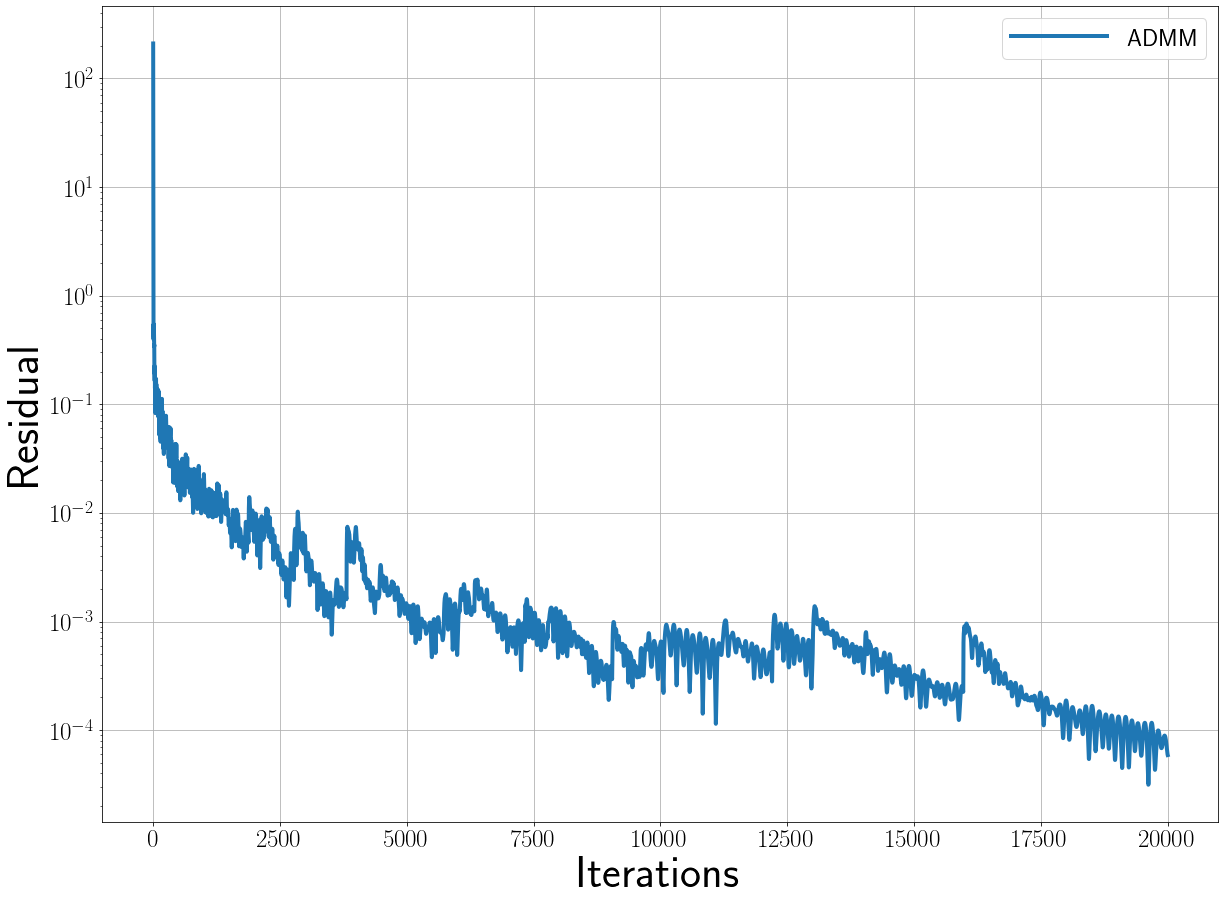

In [30]:
%matplotlib inline
plt.rc("text", usetex=True)
plt.figure(figsize=(20, 15))

hist = [np.linalg.norm(A @ z  -b) for (x, z, _), _ in method.history]
plt.semilogy(hist, label="ADMM")

plt.grid()
plt.xlabel("Iterations")
plt.ylabel("Residual")
plt.legend(loc="best", fontsize=24)

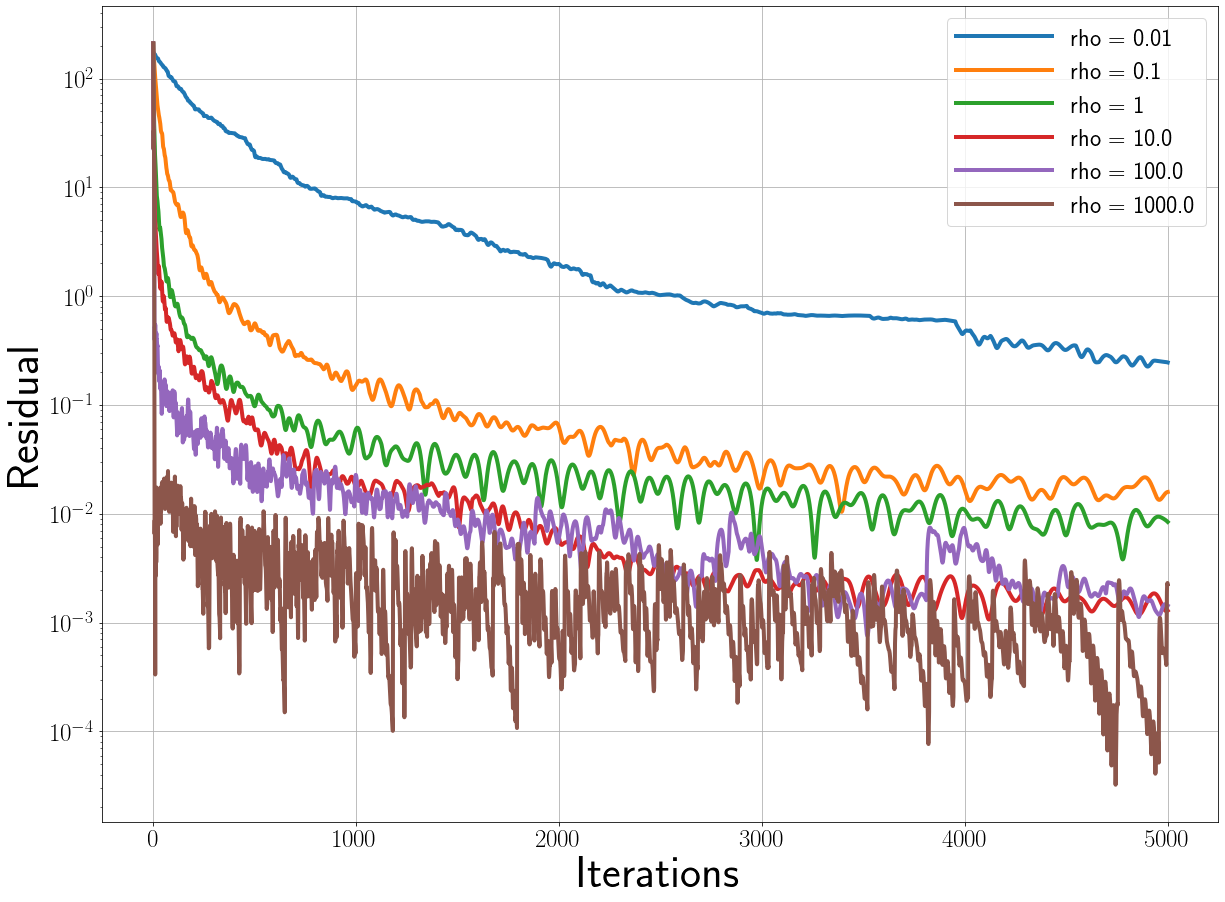

In [31]:

%matplotlib inline
plt.rc("text", usetex=True)
plt.figure(figsize=(20, 15))


for rho in [1e-2, 1e-1, 1, 1e1,1e2, 1e3]:
    method= ADMM(rho=rho, max_iters=5000, return_history=True)
    x, z, y = method.solve(x0, z0, y0, *get_params_LP(A, b, c, rho), print_iter=None)


    hist = [np.linalg.norm(A @ z  -b) for (x, z, _), _ in method.history]
    plt.semilogy(hist, label="rho = {}".format(rho))

plt.grid()
plt.xlabel("Iterations")
plt.ylabel("Residual")
plt.legend(loc="best", fontsize=24)